### This notebook demonstrates a training workflow in RealMat-BaG.

In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import pytorch_lightning as pl
import torch
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger
from torch.utils.data import DataLoader

from config import get_cfg_defaults
from realmat_bag.loaddata.cifdata import CIFData
from realmat_bag.loaddata.collate import collate_crystal_batch
from realmat_bag.pipeline.models.cgcnn.model_cgcnn import get_cgcnn_model
from realmat_bag.utils.cif_downloader import auto_download_missing_cifs_from_frame

repo_root = Path('.').resolve()
base_cfg = repo_root / 'configs/train_from_scratch/cgcnn_10.yaml'
train_out = repo_root / 'saved_models/example/cgcnn'
pred_out_dir = repo_root / 'output_test/example_ckpt_pred'
pred_out_file = pred_out_dir / 'predictions.csv'

train_out.mkdir(parents=True, exist_ok=True)
pred_out_dir.mkdir(parents=True, exist_ok=True)

print('Repo root:', repo_root)
print('Base config:', base_cfg)


Repo root: /home/haolin/PycharmProjects/benchmark_for_band_gap_prediction
Base config: /home/haolin/PycharmProjects/benchmark_for_band_gap_prediction/configs/train_from_scratch/cgcnn_10.yaml


## Step 1. Load Config and Set Example Hyperparameters

We use **CGCNN**, train on 10% of the training data, and reduce training to **2 epochs** so the notebook runs quickly.


In [2]:
cfg = get_cfg_defaults()
cfg.merge_from_file(str(base_cfg))

cfg.defrost()
cfg.MODEL.NAME = 'cgcnn'
cfg.DATASET.TRAIN = 'data/fine_tune/train_data_10.json'
cfg.DATASET.VAL = 'data/fine_tune/test_data.json'
cfg.SOLVER.EPOCHS = 2
cfg.SOLVER.WORKERS = 0
cfg.LOGGING.LOG_DIR = 'saved_models'
cfg.LOGGING.LOG_DIR_NAME = 'example/cgcnn_10_2epochs'
cfg.freeze()

print('[Example Config]')
print('MODEL.NAME:', cfg.MODEL.NAME)
print('DATASET.TRAIN:', cfg.DATASET.TRAIN)
print('DATASET.VAL:', cfg.DATASET.VAL)
print('SOLVER.EPOCHS:', cfg.SOLVER.EPOCHS)


[Example Config]
MODEL.NAME: cgcnn
DATASET.TRAIN: data/fine_tune/train_data_10.json
DATASET.VAL: data/fine_tune/test_data.json
SOLVER.EPOCHS: 2


## Step 2. Load Data and Build Data Loaders


In [3]:
def load_json_as_dataframe(path):
    with open(path, 'r') as f:
        data = json.load(f)
    df = pd.DataFrame.from_dict(data, orient='index')
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'mpids'}, inplace=True)
    return df

train_df = load_json_as_dataframe(cfg.DATASET.TRAIN)
val_df = load_json_as_dataframe(cfg.DATASET.VAL)

auto_download_missing_cifs_from_frame(
    frame=pd.concat([train_df, val_df], ignore_index=True),
    out_dir=cfg.MODEL.CIF_FOLDER,
    auto_download=True,
)

train_dataset = CIFData(
    train_df[['mpids', 'bg']],
    cfg.MODEL.CIF_FOLDER,
    cfg.MODEL.INIT_FILE,
    cfg.MODEL.MAX_NBRS,
    cfg.MODEL.RADIUS,
    cfg.SOLVER.RANDOMIZE,
)
val_dataset = CIFData(
    val_df[['mpids', 'bg']],
    cfg.MODEL.CIF_FOLDER,
    cfg.MODEL.INIT_FILE,
    cfg.MODEL.MAX_NBRS,
    cfg.MODEL.RADIUS,
    cfg.SOLVER.RANDOMIZE,
)

train_loader = DataLoader(
    train_dataset,
    collate_fn=collate_crystal_batch,
    batch_size=cfg.SOLVER.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.SOLVER.WORKERS,
)
val_loader = DataLoader(
    val_dataset,
    collate_fn=collate_crystal_batch,
    batch_size=cfg.SOLVER.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.SOLVER.WORKERS,
)

print('Train samples:', len(train_dataset))
print('Val samples:', len(val_dataset))


Train samples: 153
Val samples: 171


## Step 3. Build a CGCNN Model From Scratch



In [4]:
def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_random_seed(cfg.SOLVER.SEED)

sample = train_dataset[0]
cfg.defrost()
cfg.CGCNN.ORIG_ATOM_FEA_LEN = sample.atom_fea.shape[-1]
cfg.CGCNN.NBR_FEA_LEN = sample.nbr_fea.shape[-1]
cfg.CGCNN.POS_FEA_LEN = sample.positions.shape[-1]
cfg.freeze()

model = get_cgcnn_model(cfg)
print('Initializing model with random weights.')

print('Model class:', model.__class__.__name__)
print('Backbone class:', model.model.__class__.__name__)


Layer freezing disabled.
Initializing model with random weights.
Model class: MaterialsTrainer
Backbone class: CrystalGraphConvNet


/home/haolin/miniconda3/envs/pykale/lib/python3.11/site-packages/pytorch_lightning/core/lightning.py:2054: DeprecationWarning: `torch.distributed._sharded_tensor` will be deprecated, use `torch.distributed._shard.sharded_tensor` instead
  from torch.distributed._sharded_tensor import pre_load_state_dict_hook, state_dict_hook


## Step 4. Training


In [5]:
best_mre_checkpoint = ModelCheckpoint(
    dirpath=str(train_out),
    monitor='val_mre',
    mode='min',
    save_top_k=1,
    filename='example-best-mre-{epoch:02d}-{val_mre:.4f}',
)
last_checkpoint = ModelCheckpoint(
    dirpath=str(train_out),
    save_last=True,
    filename='example-last-{epoch:02d}',
)

csv_logger = CSVLogger(save_dir='logs', name='example_cgcnn_2ep')
trainer = pl.Trainer(
    max_epochs=cfg.SOLVER.EPOCHS,
    accelerator='cpu',
    devices=1,
    logger=csv_logger,
    callbacks=[best_mre_checkpoint, last_checkpoint],
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

best_ckpt = Path(best_mre_checkpoint.best_model_path) if best_mre_checkpoint.best_model_path else None
print('Best checkpoint:', best_ckpt)


GPU available: True, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
/home/haolin/miniconda3/envs/pykale/lib/python3.11/site-packages/pytorch_lightning/trainer/trainer.py:1584: UserWarning: GPU available but not used. Set the gpus flag in your trainer `Trainer(gpus=1)` or script `--gpus=1`.
  rank_zero_warn(

  | Name  | Type                | Params
----------------------------------------------
0 | model | CrystalGraphConvNet | 78.9 K
----------------------------------------------
78.9 K    Trainable params
0         Non-trainable params
78.9 K    Total params
0.316     Total estimated model params size (MB)
/home/haolin/miniconda3/envs/pykale/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:631: UserWarning: Checkpoint directory /home/haolin/PycharmProjects/benchmark_for_band_gap_prediction/saved_models/example/cgcnn exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty."

Validation sanity check: 0it [00:00, ?it/s]

/home/haolin/miniconda3/envs/pykale/lib/python3.11/site-packages/pytorch_lightning/trainer/data_loading.py:132: UserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/haolin/miniconda3/envs/pykale/lib/python3.11/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 20 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/haolin/miniconda3/envs/pykale/lib/python3.11/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/haolin

Training: 0it [00:00, ?it/s]

/home/haolin/miniconda3/envs/pykale/lib/python3.11/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 6 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/haolin/miniconda3/envs/pykale/lib/python3.11/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Best checkpoint: /home/haolin/PycharmProjects/benchmark_for_band_gap_prediction/saved_models/example/cgcnn/example-best-mre-epoch=01-val_mre=0.3762-v6.ckpt


## Step 5. Generate and Print Example Predictions

We run inference on the validation/test loader, print a few rows, and save the predictions as a CSV file.


In [6]:
if best_ckpt is not None and best_ckpt.exists():
    best_state = torch.load(str(best_ckpt), map_location='cpu')['state_dict']
    model.load_state_dict(best_state, strict=False)

model.eval()
rows = []
with torch.no_grad():
    for batch in val_loader:
        outputs = model(batch)
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[0]
        preds = outputs.detach().cpu().view(-1).numpy()
        gts = batch.target.detach().cpu().view(-1).numpy()
        mpids = list(batch.cif_ids)
        for mpid, gt, pred in zip(mpids, gts, preds):
            rows.append({'mpids': mpid, 'bg': float(gt), 'prediction': float(pred)})

pred_df = pd.DataFrame(rows)
pred_df.to_csv(pred_out_file, index=False)

print('Prediction file:', pred_out_file)
print('Total rows:', len(pred_df))
print(pred_df.head(10).to_string(index=False))


/tmp/ipykernel_1624226/1520122999.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_state = torch.load(str(best_ckpt), map_location='cpu')['state_dict']


Prediction file: /home/haolin/PycharmProjects/benchmark_for_band_gap_prediction/output_test/example_ckpt_pred/predictions.csv
Total rows: 171
     mpids    bg  prediction
mp-1048859 3.350    2.211638
mp-1197285 4.200    2.231991
mp-1194625 3.100    2.209327
  mp-27966 2.685    2.207535
   mp-5338 2.660    2.203748
mp-1202170 3.520    2.221538
    mp-149 1.120    2.129823
 mp-758562 2.900    2.206046
mp-1120739 3.200    2.189356
  mp-23485 2.470    2.152175


## Step 6. Render Existing 3D Saliency Figure

The combined 3D saliency implementation is available as importable Python code in `realmat_bag.analysis.material_visualization`. It reproduces the structure-level GNN interpretation figure used in the paper.


/home/haolin/PycharmProjects/benchmark_for_band_gap_prediction/realmat_bag/analysis/material_visualization.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.

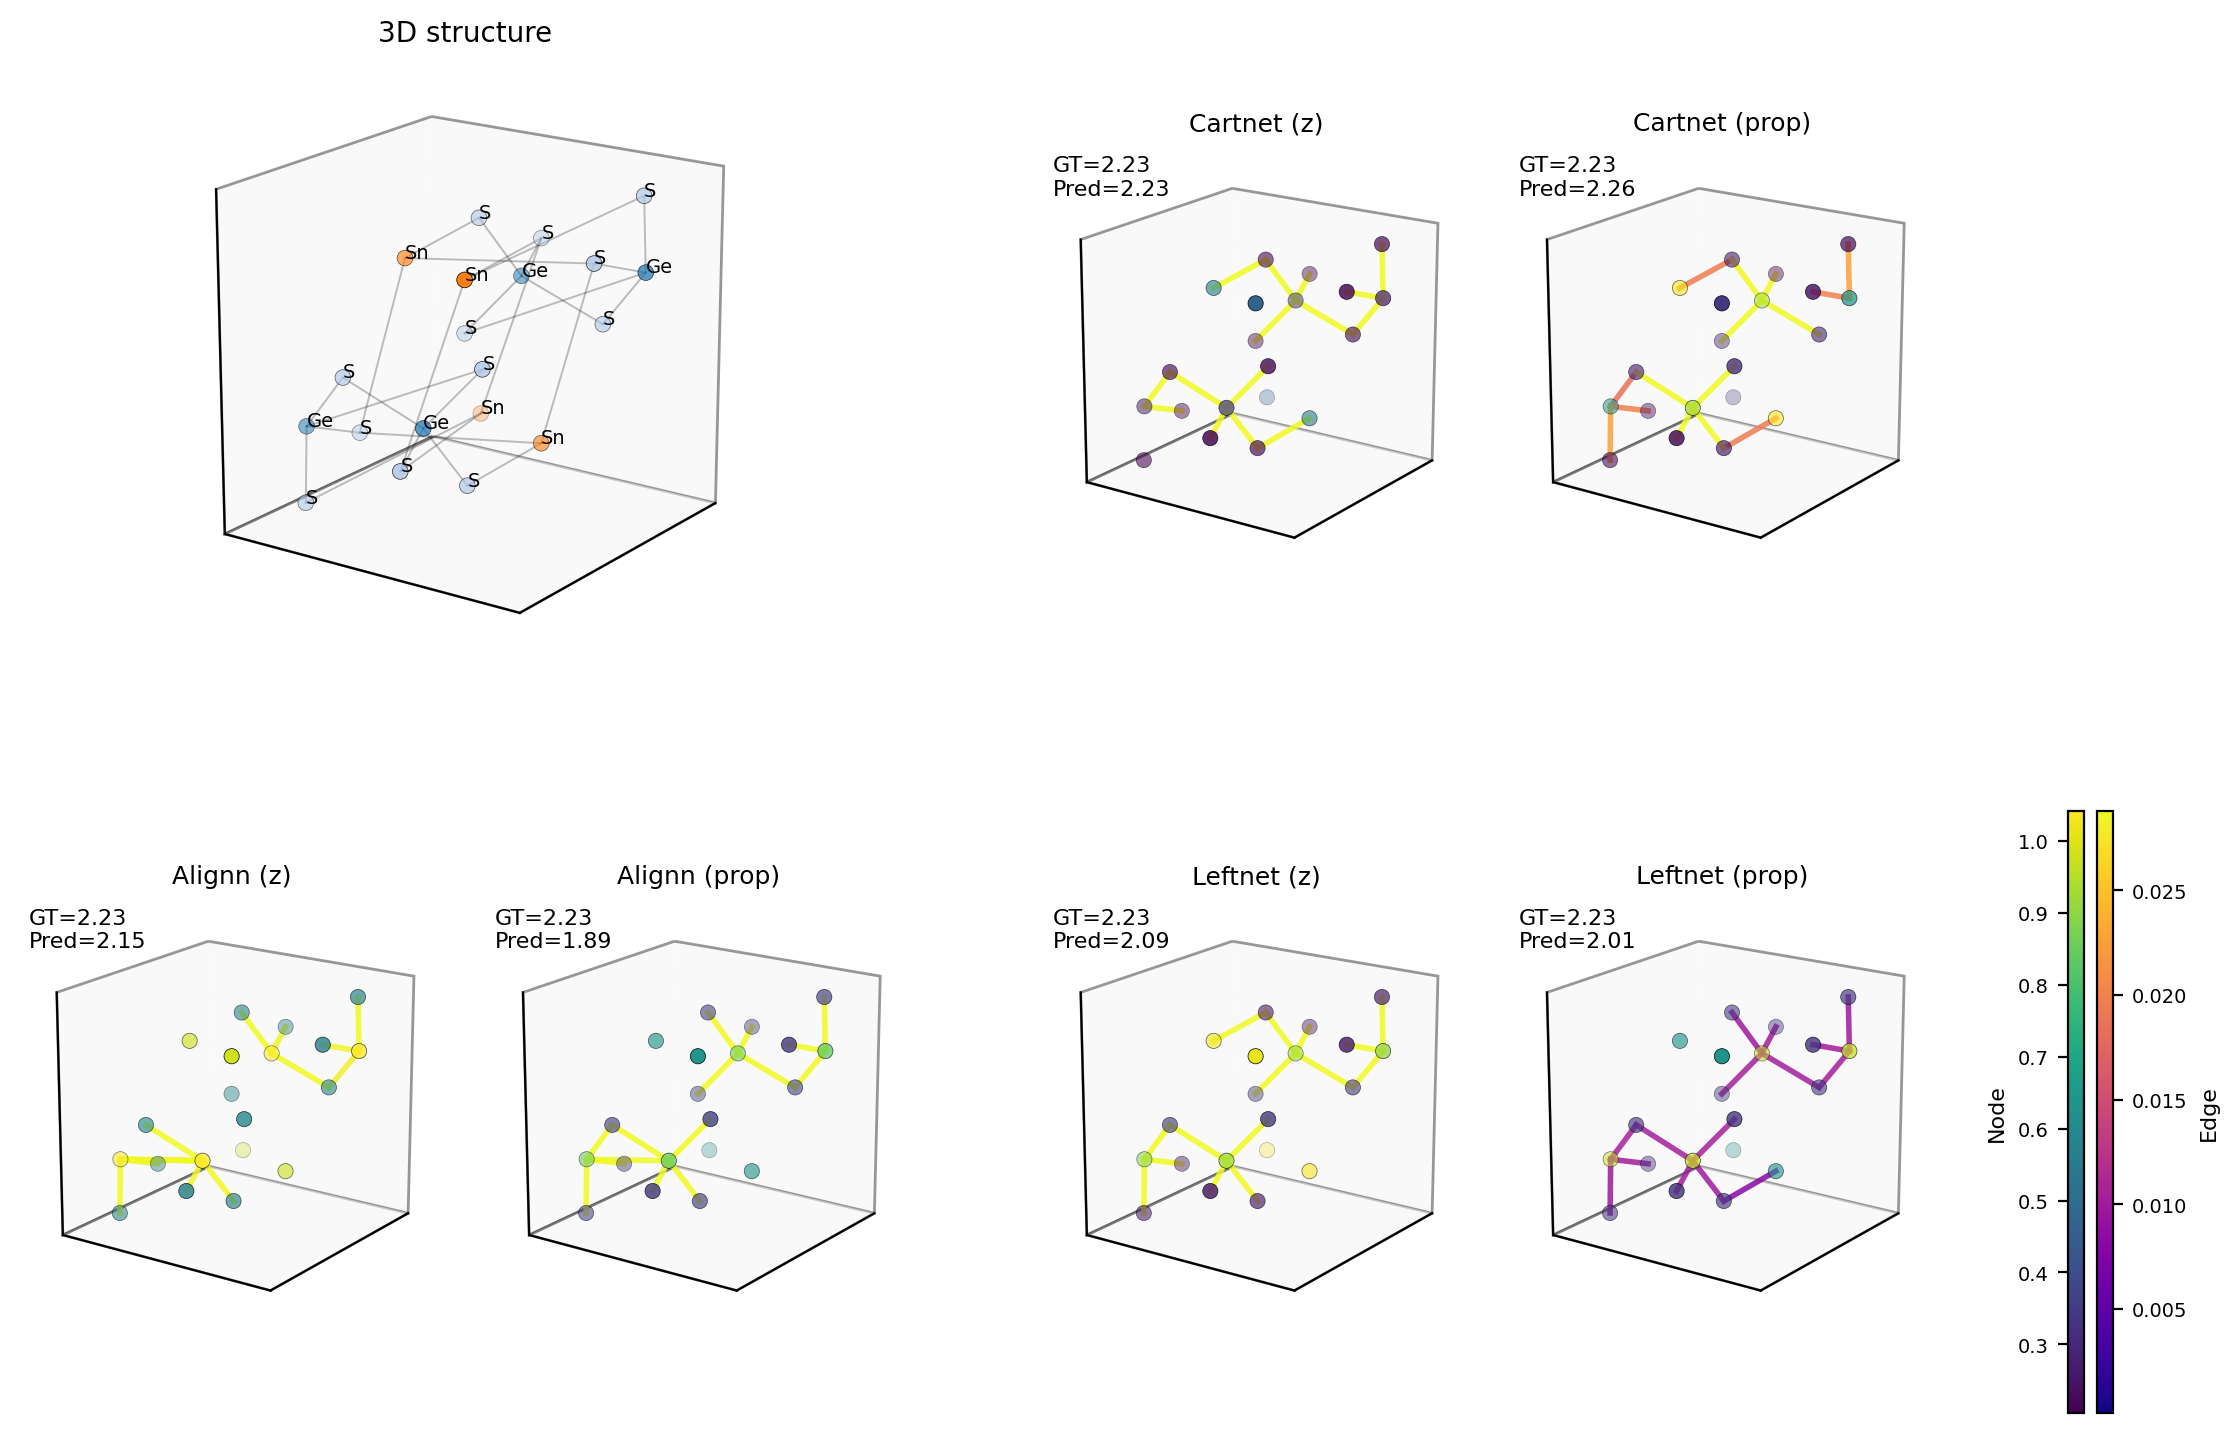

Saved -> analysis_outputs/figs/combined_3d_methods_encoding_mp-5045.png and analysis_outputs/figs/combined_3d_methods_encoding_mp-5045.pdf
Saved -> analysis_outputs/figs/combined_3d_methods_encoding_mp-5045.png


In [7]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

from realmat_bag.analysis.material_visualization import compose_encoding_saliency_figure

out_path = "analysis_outputs/figs/combined_3d_methods_encoding_mp-5045.png"
compose_encoding_saliency_figure(
    out_path=out_path,
    pt_root="analysis_outputs/saliency",
    mpid="mp-5045",
    structure_pt="analysis_outputs/saliency/leftnet_z_mp-5045_saliency_ens10.pt",
    structure_cif="cif_file/mp-5045.cif",
    architectures=["cartnet", "alignn", "leftnet"],
    topk_edges=15,
)

print(f"Saved -> {out_path}")
